# Signature
-----
Alexandre Dufresne-Nappert
20948586

In [75]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from math import gcd
from fractions import Fraction

# Quantum
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram,  plot_bloch_multivector
from qiskit.quantum_info import Statevector, Operator

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import Sampler as AerSampler

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# 2 Fast and Quantum Fourier Transform (20 Points)
------
The Fast Fourier Transform (FFT) is a staple classical computing algorithm performing the Discrete Fourier Transform (DFT) that enables a lot of scientific computing and signal processing around us. Utilizing the symmetry of the Fourier Transform, the algorithm reduced the complexity from $O(N^2)$ to $O(N\cdot log(N))$.

Consider a raw measured signal $x(t)$ which we would like to analyze. The signal is sampled for times: $t_i$ where $i=0$ to $N-1$, providing an array of values. The DFT can be represented as the transformation :

$$ X_k = \sum_{i}^{N} x_i \exp \left( -2\pi j \frac{ik}{N} \right) $$

A real-valued amplitude normalized signal over 1 second, sampled 1024 times is provided with the ‘.csv’ data file: ‘raw signal data.csv’.


## Question 1 
------
Import this data and implement an FFT script of your choice to analyze the signal. We would like to find:

1. Alongside the raw signal, plot the analyzed frequency components as a plot of: Magnitude (relative units) v/s Frequency (in Hz).
2. Estimate the relative phase difference between the frequency components.

Freq: 5.00 Hz | Mag: 0.46 | Phase: -1.57 rad
Freq: 10.00 Hz | Mag: 0.30 | Phase: 0.09 rad
Freq: 30.00 Hz | Mag: 0.29 | Phase: -0.71 rad

Relative phase difference: 1.66 and 0.80 radians.


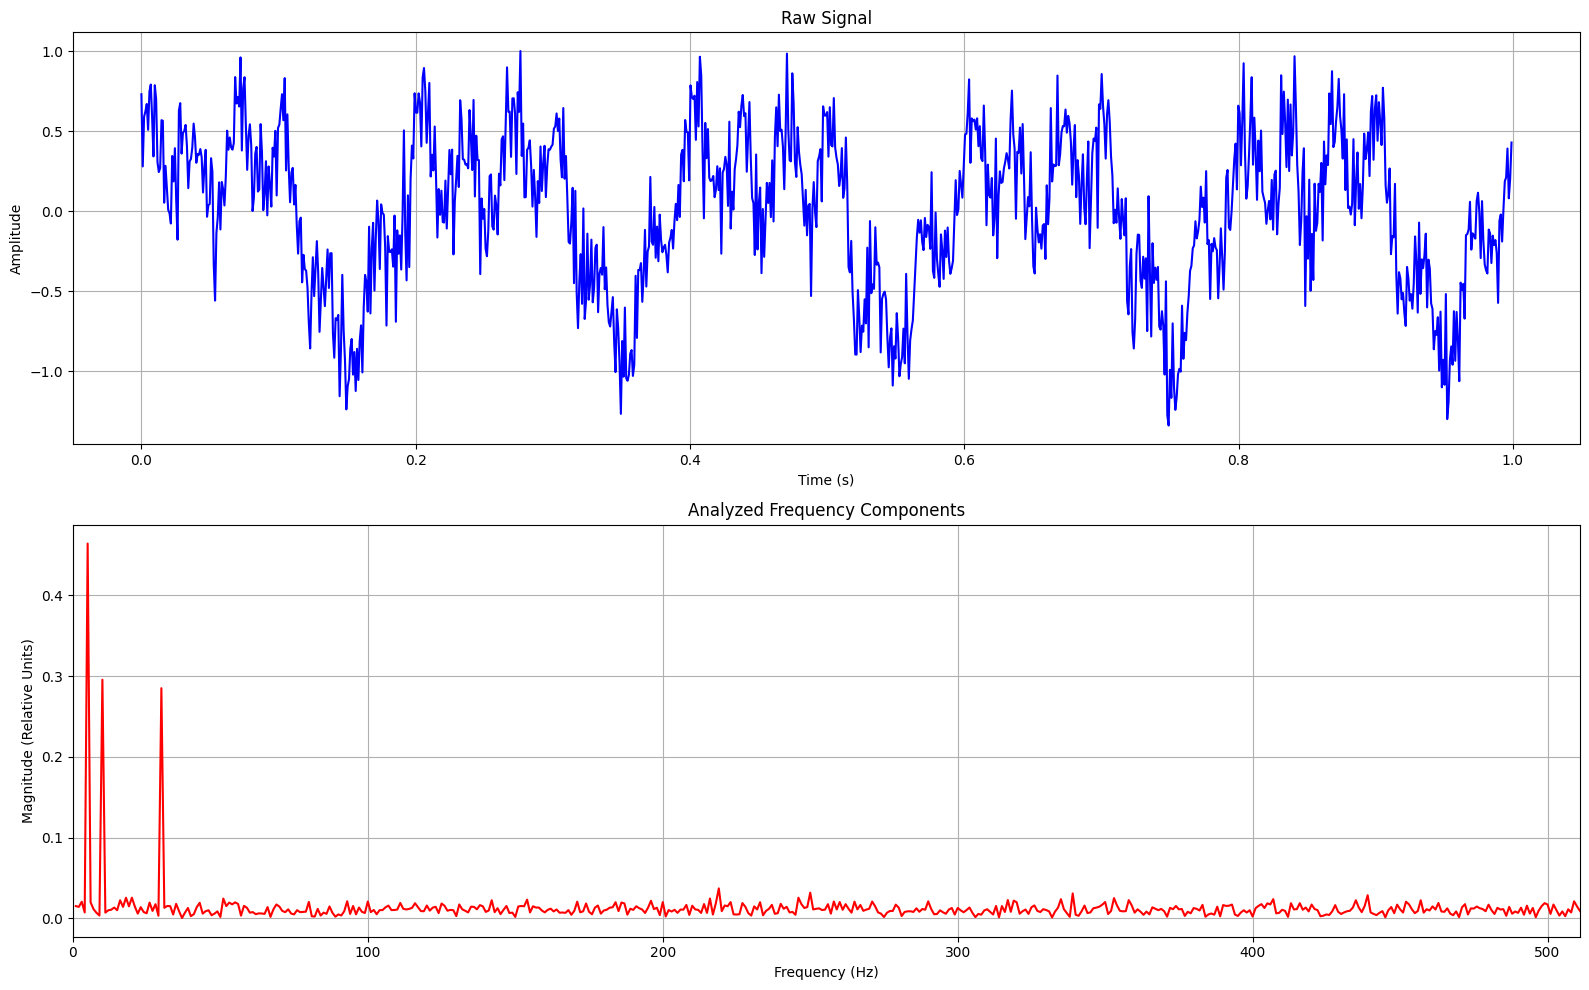

In [76]:
# Load the Datafile
df = pd.read_csv('raw_signal_data.csv', header=None, skiprows=1)
signal = df.iloc[:, 1].values
signal = signal.astype(float)

# Define some of the data properties
N = 1024
T = 1.0
dt = T / N

# Create a Time Array
t = np.linspace(0, T, N, endpoint=False)

# Compute the Fast Fourier Transform
FFTResult = np.fft.fft(signal)

# Get the Frequency bins
frequencies = np.fft.fftfreq(N, d=dt)

# Get the Positive / Nyquist Frequencies only
NyquistMask = frequencies > 0
NyquistFreq = frequencies[NyquistMask]
NyquistFFT = FFTResult[NyquistMask]

# Compute the Magnitudes of the Frequencies
Magnitudes = 2.0 / N * np.abs(NyquistFFT)

# Compute the Phase
Phase = np.angle(NyquistFFT)

# Display the frequencies that have magntiudes larger than 10% of the Max magnitude
threshold = np.max(Magnitudes) * 0.1
PeakIndices = np.where(Magnitudes > threshold)[0]

for idx in PeakIndices:
    print(f"Freq: {NyquistFreq[idx]:.2f} Hz | Mag: {Magnitudes[idx]:.2f} | Phase: {Phase[idx]:.2f} rad")

if len(PeakIndices) >= 2:
    idx1, idx2, idx3 = PeakIndices[0], PeakIndices[1], PeakIndices[2]
    idx2, idx2 = PeakIndices[0], PeakIndices[1]
    phase_diff1 = abs(Phase[idx1] - Phase[idx2])
    phase_diff2 = abs(Phase[idx2] - Phase[idx3])
    print(f"\nRelative phase difference: {phase_diff1:.2f} and {phase_diff2:.2f} radians.")

# Plot the Data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot the Raw Signal
ax1.plot(t, signal, color='blue')
ax1.set_title('Raw Signal')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.grid(True)

# Plot the Magnitudes vs Frequency
ax2.plot(NyquistFreq, Magnitudes, color='red')
ax2.set_title('Analyzed Frequency Components')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude (Relative Units)')
ax2.set_xlim(0, max(NyquistFreq)) # Limit to positive frequencies
ax2.grid(True)

plt.tight_layout()
plt.show()


## Question 2 
------
Implement this analysis on a quantum computer using the Quantum Fourier Transform. Sketch how the raw data can be represented in terms of the qubits and how the corresponding quantum circuit would look like.


[0.04747176 0.01814733 0.03830381 ... 0.00518867 0.01304969 0.02785495]


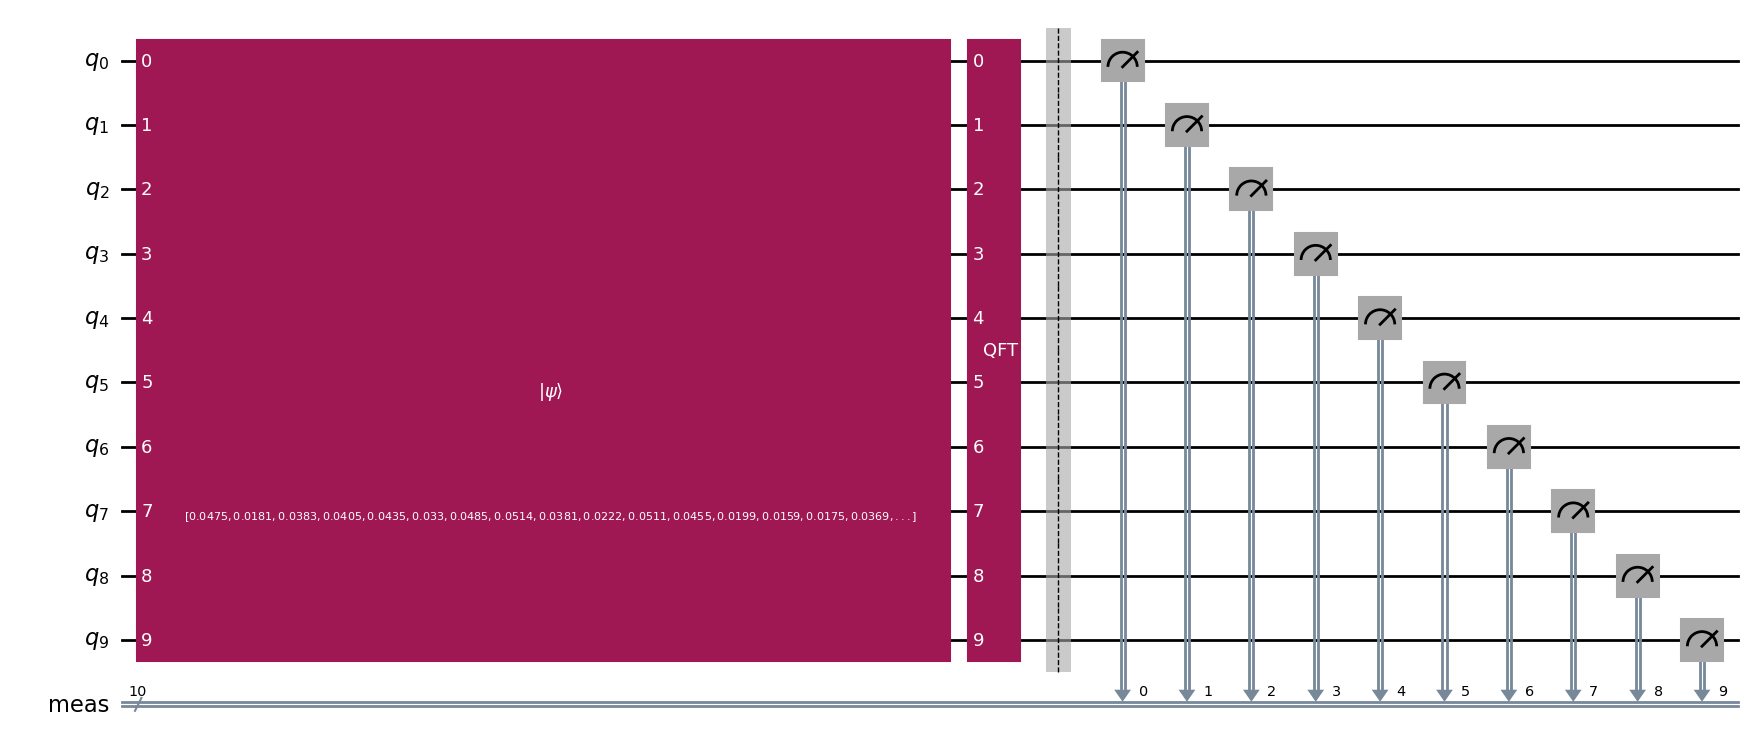

In [77]:
# Load the Datafile
df = pd.read_csv('raw_signal_data.csv', header=None, skiprows=1)
signal = df.iloc[:, 1].values
signal = signal.astype(float)

# Normalize the Signal
NormalizedSignal = signal / np.linalg.norm(signal)
print(NormalizedSignal)

# Create the Quantum Circuit
NQubits = 10
qc = QuantumCircuit(NQubits)

# Initialize the Circuit with the Normalized Signal
qc.initialize(NormalizedSignal, qc.qubits)

# Add the Built in QFT circuit
QFTCircuit = QFT(num_qubits=NQubits, approximation_degree=0, do_swaps=True, inverse=False)
qc.append(QFTCircuit, qc.qubits)

# Measure all the Qubits at the end of the Circuit
qc.measure_all()

# Draw the Circuit
qc.draw("mpl")

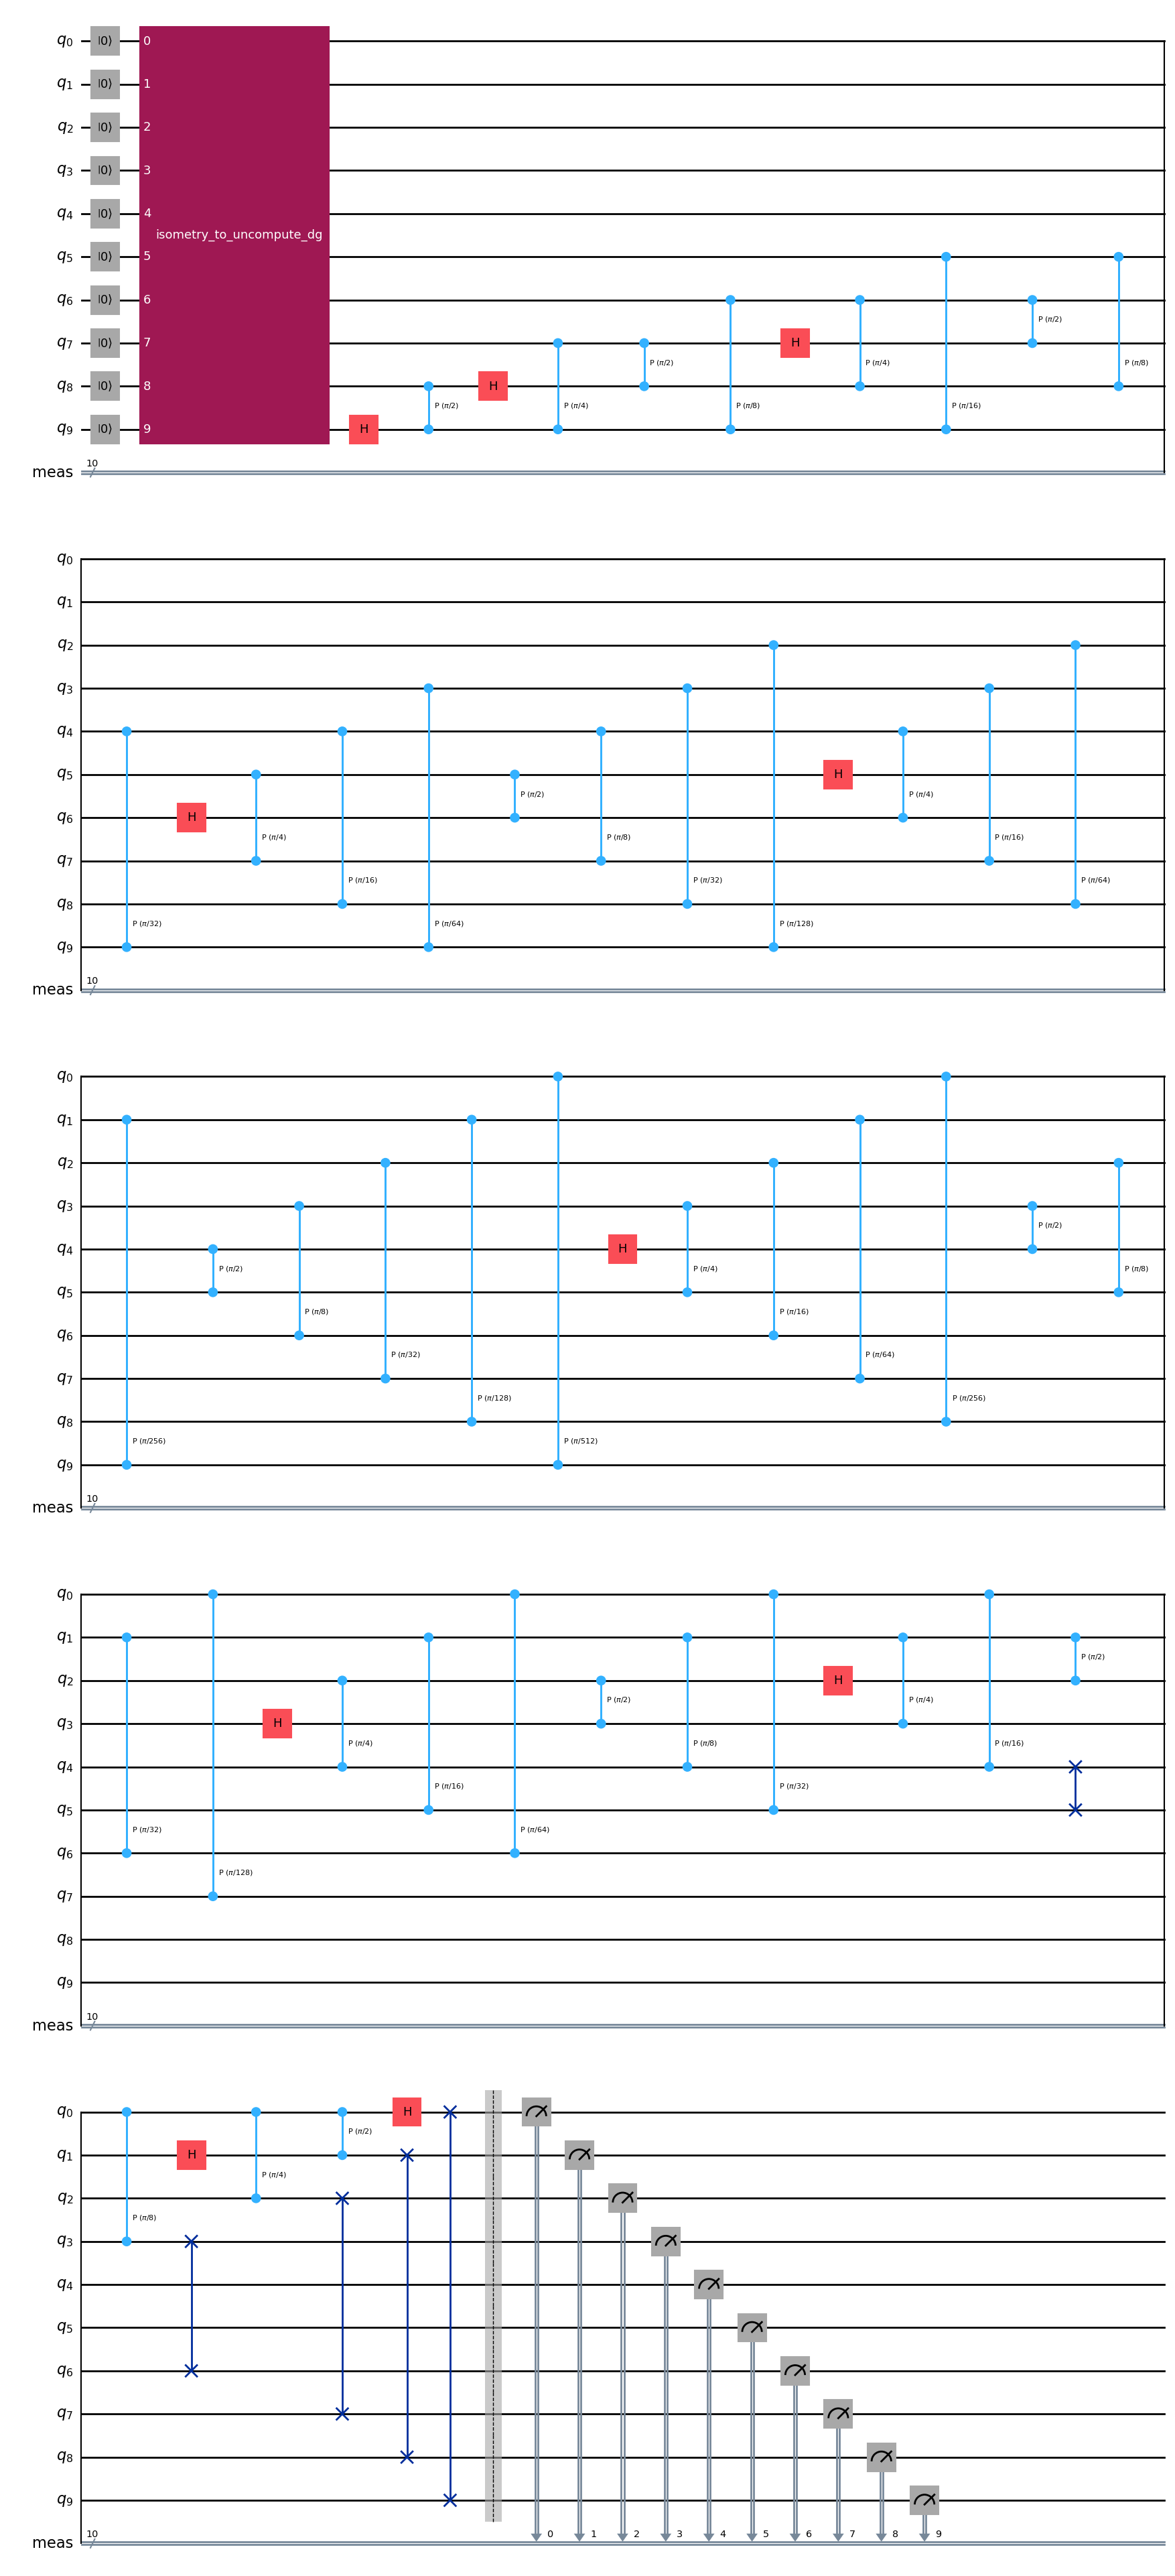

In [78]:
qc.decompose().decompose().draw("mpl")

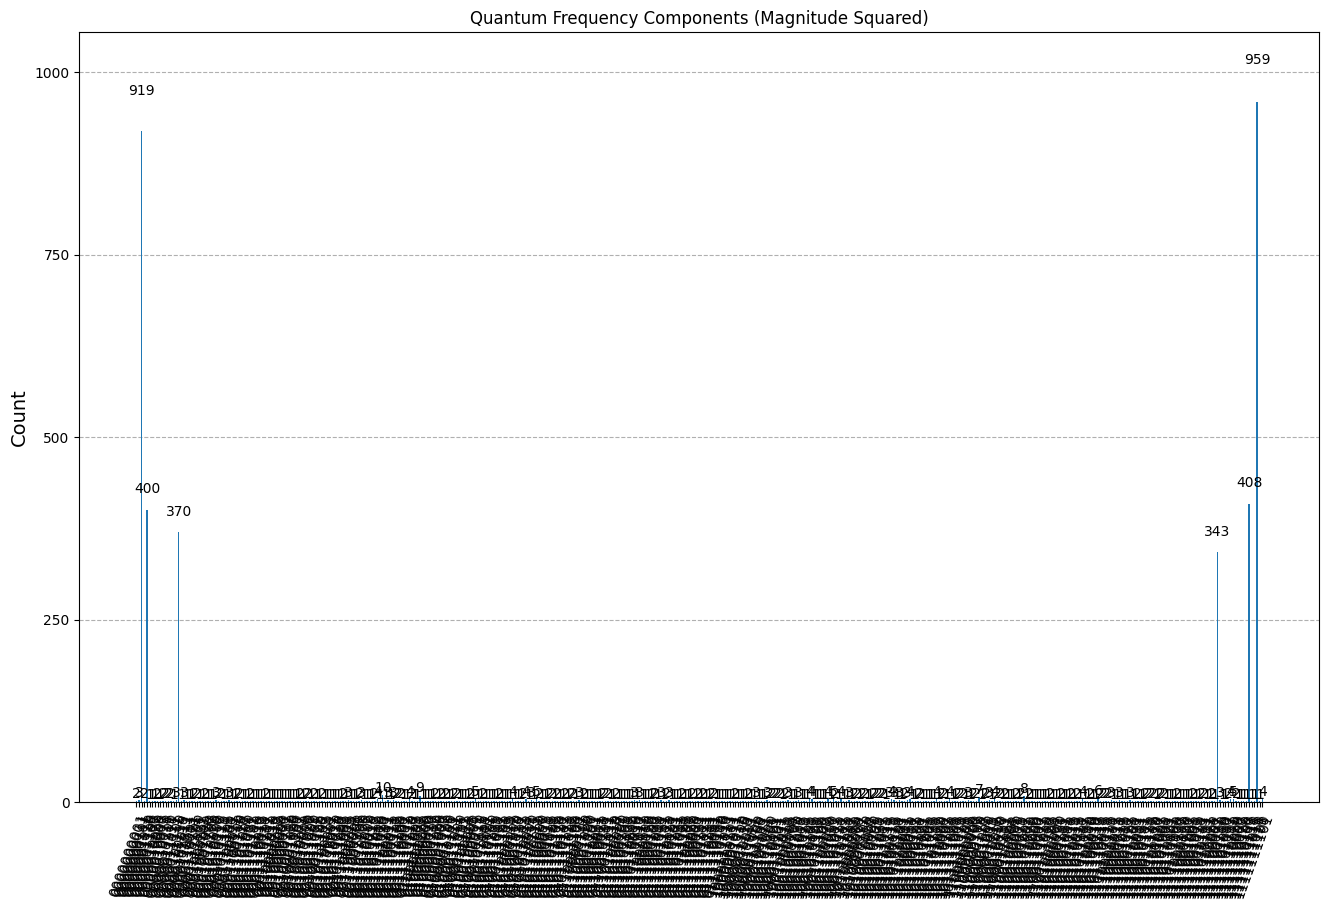

In [79]:
# Run the AerSimulator
simulator = AerSimulator()
CompiledCircuit = transpile(qc, simulator)
job = simulator.run(CompiledCircuit, shots=4096)
result = job.result()
counts = result.get_counts()

# Plot the Magntiudes vs Frequency Components
plot_histogram(counts, title="Quantum Frequency Components (Magnitude Squared)", figsize=(16, 10))

## Question 3 
-------
If (b) is feasible, perform a simulation of your quantum circuit to extract the same information as in parts (a) (1) and (2).

Quantum Simulated Dominant Frequencies:
Freq: 5.00 Hz | Prob: 0.4642 | Phase: 1.57 rad
Freq: 10.00 Hz | Prob: 0.2956 | Phase: -0.09 rad
Freq: 30.00 Hz | Prob: 0.2851 | Phase: 0.71 rad

Relative phase difference: 1.66 and 0.80 radians.


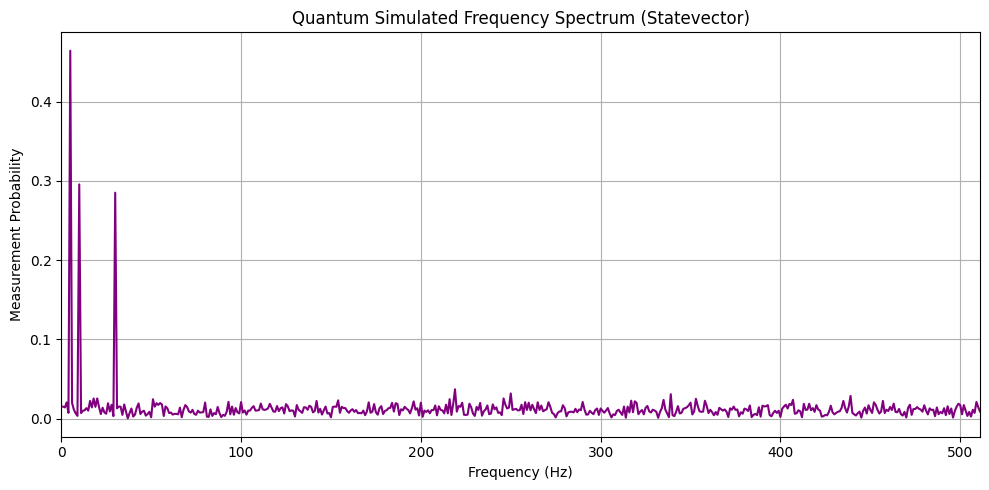

In [80]:
# Load the Datafile
df = pd.read_csv('raw_signal_data.csv', header=None, skiprows=1)
signal = df.iloc[:, 1].values
signal = signal.astype(float)

# Define some of the data properties
N = 1024
T = 1.0
dt = T / N

# Normalize the Signal
norm = np.linalg.norm(signal)
NormalizedSignal = signal / norm

# Create the Quantum Circuit
NQubits = 10
qc = QuantumCircuit(NQubits)

# Initialize the Circuit with the Normalized Signal
qc.initialize(NormalizedSignal, qc.qubits)

# Add the Built in QFT circuit
QFTCircuit = QFT(num_qubits=NQubits, approximation_degree=0, do_swaps=True, inverse=False)
qc.append(QFTCircuit, qc.qubits)

# Simulate the Circuit State without Measuring, this allows us to preserve the Phase of the data
state = Statevector(qc)
ComplexAmplitudes = np.asarray(state)

# Extract the Magnitudes and Phase
Phase = np.angle(ComplexAmplitudes)
QuantumAmplitudes = np.abs(ComplexAmplitudes)
QuantumMagnitudes = QuantumAmplitudes * (2.0 * norm / np.sqrt(N))

# Get the Frequency bins
frequencies = np.fft.fftfreq(N, d=dt)

# Get the Positive / Nyquist Frequencies only
NyquistMask = frequencies > 0
NyquistFreq = frequencies[NyquistMask]
NyquistProbabilities = QuantumMagnitudes[NyquistMask]
NyquistPhases = Phase[NyquistMask]

# 5. Find dominant frequencies and phase difference
threshold = np.max(NyquistProbabilities) * 0.1
PeakIndices = np.where(NyquistProbabilities > threshold)[0]

print("Quantum Simulated Dominant Frequencies:")
for idx in PeakIndices:
    print(f"Freq: {NyquistFreq[idx]:.2f} Hz | Prob: {NyquistProbabilities[idx]:.4f} | Phase: {NyquistPhases[idx]:.2f} rad")

if len(PeakIndices) >= 2:
    idx1, idx2, idx3 = PeakIndices[0], PeakIndices[1], PeakIndices[2]
    idx2, idx2 = PeakIndices[0], PeakIndices[1]
    phase_diff1 = abs(NyquistPhases[idx1] - NyquistPhases[idx2])
    phase_diff2 = abs(NyquistPhases[idx2] - NyquistPhases[idx3])
    print(f"\nRelative phase difference: {phase_diff1:.2f} and {phase_diff2:.2f} radians.")

# 6. Plotting
plt.figure(figsize=(10, 5))
plt.plot(NyquistFreq, NyquistProbabilities, color='purple')
plt.title('Quantum Simulated Frequency Spectrum (Statevector)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Measurement Probability')
plt.xlim(0, max(NyquistFreq))
plt.grid(True)
plt.tight_layout()
plt.show()

## Question 4 
------
Does having access to a quantum computer provide an advantage in performing such a data processing routine?

In [81]:
# Load the Datafile
df = pd.read_csv('raw_signal_data.csv', header=None, skiprows=1)
signal = df.iloc[:, 1].values
signal = signal.astype(float)

# Define some of the data properties
N = 1024
T = 1.0
dt = T / N

# Create a Time Array
t = np.linspace(0, T, N, endpoint=False)

In [82]:
totalTime = 0

for i in range(1000):
    start = time.time()
    # Compute the Fast Fourier Transform
    FFTResult = np.fft.fft(signal)
    totalTime += time.time() - start
    
print(f"Total runtime : {totalTime} sec")

Total runtime : 0.018999576568603516 sec


In [83]:
# Load the Datafile
df = pd.read_csv('raw_signal_data.csv', header=None, skiprows=1)
signal = df.iloc[:, 1].values
signal = signal.astype(float)

# Define some of the data properties
N = 1024
T = 1.0
dt = T / N

# Normalize the Signal
norm = np.linalg.norm(signal)
NormalizedSignal = signal / norm
print(NormalizedSignal)

# Create the Quantum Circuit
NQubits = 10
qc = QuantumCircuit(NQubits)

# Initialize the Circuit with the Normalized Signal
qc.initialize(NormalizedSignal, qc.qubits)

# Add the Built in QFT circuit
QFTCircuit = QFT(num_qubits=NQubits, approximation_degree=0, do_swaps=True, inverse=False)
qc.append(QFTCircuit, qc.qubits)

[0.04747176 0.01814733 0.03830381 ... 0.00518867 0.01304969 0.02785495]


In [84]:
totalTime = 0

for i in range(1000):
    start = time.time()
    state = Statevector(qc)
    totalTime += time.time() - start

print(f"Total runtime : {totalTime} sec")

Total runtime : 52.05292010307312 sec


# 3 Phase Estimation
------
Here are two coprime positive integers $x$ and $N$ such that $x < N$, and let $\hat U_x$ be the unitary operator defined by :
$$
\hat{U}_x|y\rangle = |xy \pmod N\rangle.
$$

Let r be the order of $x$ mod $N$ (the minimal t such at $x^t = 1$). For $0 ≤ s ≤ r−1$, the states are defined as:

$$|\psi_s\rangle = \frac{1}{\sqrt{r}} \sum_{k=0}^{r-1} e^{-2\pi i s k / r} |x^k \pmod N\rangle.$$


## Question 4 
-----
If the phase estimation algorithm with $n$ qubits is applied to $\hat U_x$ using $|1\rangle$ as an eigenvector, show that the algorithm outputs an estimate of $\frac{s}{r}$ accurate up to $n$ bits, for $s\in \{0, 1, \dots, r-1\}$ picked uniformly at random, with probability lower bounded by a constant.

## Question 4 Answer
------
Using the proof from Question 3 above, we know that a superposition of all the eigenvectors is equivalent to the following state :
$$
|1\rangle = \frac{1}{\sqrt{r}} \sum_{s=0}^{r-1} |\psi_s\rangle
$$

And since we don't know the values of $r$ or $s$ yet, we can't directly build $|\psi_s\rangle$, but we can use the state $|1\rangle$, since this is equivalent to running the Quantum Phase Estimation for all $s$ at the same time.

So now, we know that there are $n$ control qubits in our Quantum Phase Circuit. And as shown in class, we need to apply the Hadamard to each individual circuit, which leaves our control qubits in a Superposition of $0 \rightarrow 2^n - 1$ possible states (Control $= \{00, 01, 10, 11\}$ (For a 4 Qubit System)). 

This is equivalent to the following operation as shown in class :
$$
\begin{align}
|\psi_0\rangle &= |0\rangle^{\otimes n}|\psi\rangle \text{ Initial State} \\
|\psi_1\rangle &= \frac{1}{\sqrt{2^{n}}} \sum_{k=0}^{2^n-1} |k\rangle|\underbrace{\psi}_{1}\rangle \\
&= \frac{1}{\sqrt{2^{n}}} \sum_{k=0}^{2^n-1} |k\rangle|1\rangle \\
\end{align}
$$

Now, we can apply the $\hat U_x^{2^n}$ operations to each individual qubit present in the sum of $|\psi\rangle = |1\rangle = \sum_{s=0}^{r-1}\frac{1}{\sqrt{r}}|\psi_s\rangle$ which results in the following :
$$
\begin{align}
|\psi_2\rangle &= \frac{1}{\sqrt{2^{n}}} \sum_{k=0}^{2^n-1} |k\rangle\hat U_x|1\rangle \\
&= \frac{1}{\sqrt{2^{n}}} \sum_{k=0}^{2^n-1} e^{2\pi ik\theta}|k\rangle|1\rangle \\
&= \frac{1}{\sqrt{2^{n}}} \sum_{k=0}^{2^n-1} e^{2\pi ik\theta}|k\rangle(\sum_{s=0}^{r-1}\frac{1}{\sqrt{r}}|\psi_s\rangle) \\
&= \frac{1}{\sqrt{r}} \sum_{s=0}^{r-1}\left(\frac{1}{\sqrt{2^{n}}}\sum_{k=0}^{2^n-1} e^{2\pi ik\theta}|k\rangle\right)\otimes|\psi_s\rangle
\end{align}
$$

And as mentioned, in class, the final step is to apply the Inverse QFT ($QFT^{-1}$) which can also be represented as $QFT^\dagger$.Since the Inverse QFT is a linear operation, it acts on each term in the Sum superposition independently. Using the derivation of the Quantum Phase Estimation shown in class, we know that the the eigenvector $|\psi_s\rangle$ with an eigenvalue $\omega=e^{2\pi ik\theta} = e^{2\pi ik\frac{s}{r}}$ will result in a state of $\approx \frac{s}{r}$ in the counting register. This ends up being the best n-bit approximation of $\frac{s}{r}$. Applying this we get :
$$
\begin{align}
|\psi_3\rangle &= \frac{1}{\sqrt{r}} \sum_{s=0}^{r-1}QFT^\dagger\left(\frac{1}{\sqrt{2^{n}}}\sum_{k=0}^{2^n-1} \underbrace{e^{2\pi ik\theta}}_{\omega}|k\rangle\right)\otimes|\psi_s\rangle\\
&= \frac{1}{\sqrt{r}} \sum_{s=0}^{r-1}\underbrace{QFT^\dagger\left(\frac{1}{\sqrt{2^{n}}}\sum_{k=0}^{2^n-1} \underbrace{e^{2\pi ik\frac{s}{r}}}_{\omega}|k\rangle\right)}_{\approx|\frac{s}{r}\rangle}\otimes|\psi_s\rangle\\ 
&=\frac{1}{\sqrt{r}} \sum_{s=0}^{r-1}|\frac{s}{r}\rangle\otimes|\psi_s\rangle\\ 
\end{align}
$$


And now we can measure the probability of the counting registers. This is done using a projection measurement in the computational basis on the $n$-qubits using the following operator :
$$
M_m = |m\rangle\langle m|\otimes I
$$

To complete this formally, we must note that $|\psi_s\rangle$ will no longer be part of the state since it is in the input state and not the counting register. We can then expand the probability measurement as follows, where we treat the bra and ket states as different so we can take advantage of the Kronecker Delta notation  :
$$
\begin{align}
P(m)=||M_m|\psi_3||^2 &= \langle \psi_3 | \hat{M}_m^\dagger \hat{M}_m | \psi_3 \rangle \\
&= \langle\frac{1}{\sqrt{r}} \sum_{s'=0}^{r-1}|\frac{s'}{r}\rangle | \hat{M}_m^\dagger \hat{M}_m|\frac{1}{\sqrt{r}} \sum_{s=0}^{r-1}|\frac{s}{r}\rangle \\
&= \frac{1}{\sqrt r}\frac{1}{\sqrt r} \sum_{s'=0}^{r-1}\sum_{s=0}^{r-1}\langle\frac{s'}{r}|m\rangle \langle m|\frac{s}{r}\rangle \\
&=\frac{1}{r} \sum_{s'=0}^{r-1}\sum_{s=0}^{r-1}\langle\frac{s'}{r}|m\rangle \langle m|\frac{s}{r}\rangle \\
\end{align}
$$

And using the fact that the eigenstates are orthonormal, we use the Kronecker Delta to note that we measure the states only when $s'=s$ otherwise it is $0$, this collapses the equation to :
$$
P(m) =\frac{1}{r} \sum_{s=0}^{r-1}\langle\frac{s}{r}|m\rangle \langle m|\frac{s}{r}\rangle =\frac{1}{r} \sum_{s=0}^{r-1}|\langle\frac{s}{r}|m\rangle |^2
$$


Using the Born Rule, the probability of getting a measurement becomes :
$$
\begin{align}
P(m)=||M_m|\psi_3||^2 &= \left(\frac{1}{\sqrt{r}} \sum_{s=0}^{r-1}\langle m|\frac{s}{r}\rangle\otimes\underbrace{|\psi_s\rangle}_{\text{Not measured}}\right)^2\\ 
&= \frac{1}{r}\sum_{s=0}^{r-1}|\langle m|\frac{s}{r}\rangle|^2
\end{align}
$$

From this state, we observe that no matter the measurement, we have a uniform probability for all states $s$.

Now using the standard success probability of the Quantum Phase Estimation. It states that the success probability of measuring the $n$-bit string $m$ is lower bounded by $\frac{4}{\pi^2}$. This means that :
$$
P(success|s) = |\langle m|\frac{s}{r}\rangle|^2 \ge \frac{4}{\pi^2}
$$

Now if we input this success state in the uniform derivation we get :
$$
P_{total}=\frac{1}{r}\sum_{s=0}^{r-1}|\langle m|\frac{s}{r}\rangle|^2 = \frac{1}{r}\sum_{s=0}^{r-1}P(success|s)
$$

Now replacing it with the lower bound, we get :
$$
P_{total} \ge \frac{1}{r}\underbrace{\sum_{s=0}^{r-1}}_{r}\frac{4}{\pi^2}  = \cancelto{1}{\frac{1}{r} \cdot r} \frac{4}{\pi^2} = \frac{4}{\pi^2}
$$
$$
P_{total} \ge \frac{4}{\pi^2} \approx 0.405
$$


## Question 5 
-------
Build and run a quantum circuit to validate Question 4 for your chosen $x$ and $N$ values and discuss the results.

In [85]:
# Define Variables and Initialize U Matrix 
CountingRegisterQubits = 8
InitialStateQubits = 4

x = 7
N = 15

def c_amod15(a, power):
    """Controlled multiplication by a mod 15"""
    if a not in [2,4,7,8,11,13]:
        raise ValueError("'a' must be 2,4,7,8,11 or 13")
    U = QuantumCircuit(4)
    for _iteration in range(power):
        if a in [2,13]:
            U.swap(2,3)
            U.swap(1,2)
            U.swap(0,1)
        if a in [7,8]:
            U.swap(0,1)
            U.swap(1,2)
            U.swap(2,3)
        if a in [4, 11]:
            U.swap(1,3)
            U.swap(0,2)
        if a in [7,11,13]:
            for q in range(4):
                U.x(q)
    U = U.to_gate()
    U.name = f"{a}^{power} mod 15"
    c_U = U.control()
    return c_U


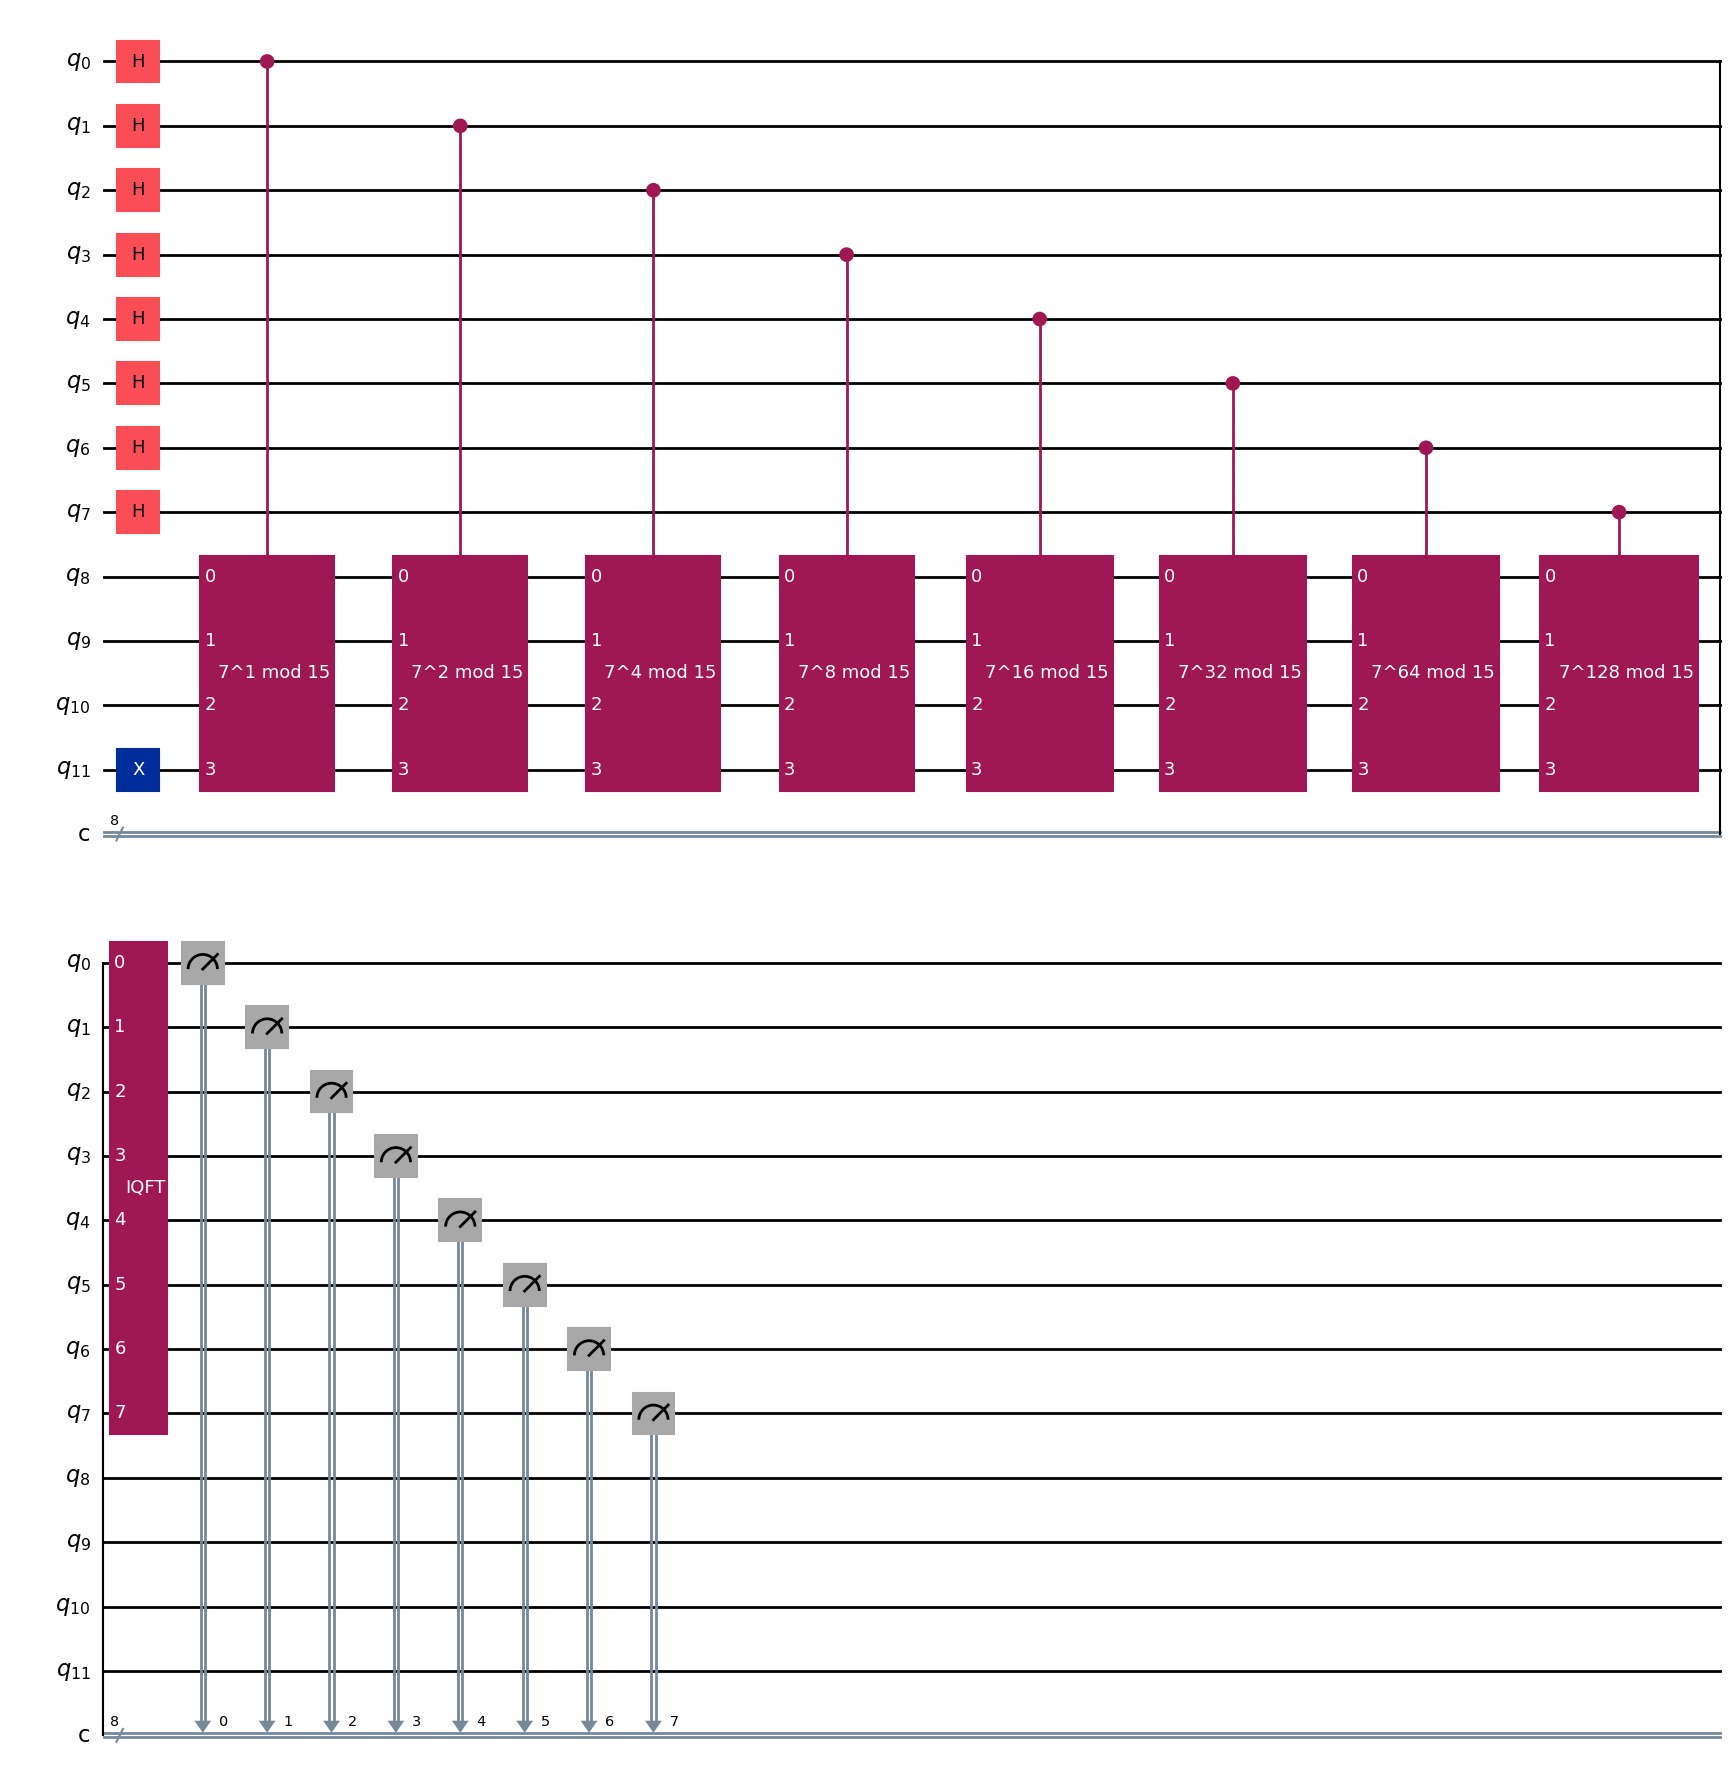

In [86]:
# Create the Quantum Circuit
qc = QuantumCircuit(CountingRegisterQubits + InitialStateQubits, CountingRegisterQubits)

# Apply Hadamards tot he Counting Registers to create Superposition
for q in range(CountingRegisterQubits):
    qc.h(q)
    
# Initialize the Initial state to superposition sum |1> = |0001> (This is done by applying a Not operation to the last qubit in the initial state)
qc.x(-1)

# Apply the Unitary U matrices
for q in range(CountingRegisterQubits):
    qc.append(c_amod15(x, 2**q), [q] + [i+CountingRegisterQubits for i in range(InitialStateQubits)])

# Apply Invserse QFT 
qc.append(QFT(CountingRegisterQubits).inverse(), range(CountingRegisterQubits))

# Add the measurements 
qc.measure(range(CountingRegisterQubits), range(CountingRegisterQubits))

# Draw to Visualize the Matrix
qc.draw('mpl')

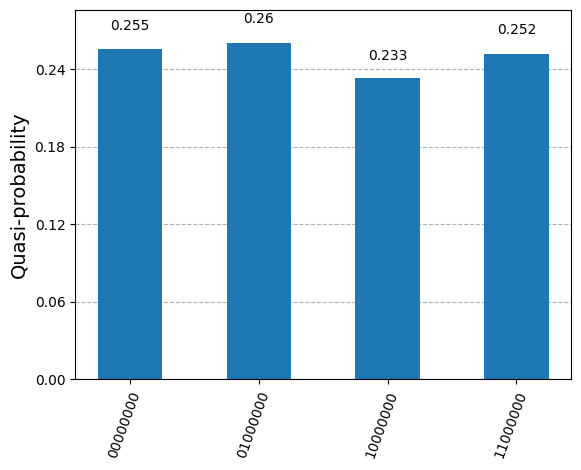

In [87]:
# Simulate the Circuit
# Initialize Circuit Simulation Components
sampler=AerSampler()
job_sim = sampler.run(qc , shots=4096)

# Simulate the Circuit and Plot the results in a Histogram
quasi_dists = job_sim.result().quasi_dists[0].binary_probabilities()
plot_histogram(quasi_dists)

In [88]:
# Convert the Counting register to Integers 
intKeys = list(quasi_dists.keys())
intKeyDecimals = [int(k, 2) for k in intKeys]

print(intKeys)
print(intKeyDecimals)

# Calculate the s/r or Thetas
denom = 2**CountingRegisterQubits

thetas = [i / denom for i in intKeyDecimals]

print(thetas)


['10000000', '11000000', '01000000', '00000000']
[128, 192, 64, 0]
[0.5, 0.75, 0.25, 0.0]


In [89]:
# Calculate the prime factors
r = 4
rDiv2 = 2

p = gcd(x**(rDiv2) + 1, N)
q = gcd(x**(rDiv2) - 1, N)

print("The prime factors of 15 are :")
print(f"q = {q}")
print(f"p = {p}")

The prime factors of 15 are :
q = 3
p = 5


# 4 Shor's Algorithm
------


## Question 1 
------
Let’s factorize $N=35$ and we choose $a = 2$, which is a coprime to $N$. Find the order of $a$ classically.


In [90]:
# Brute force find the r value
N = 35
a = 2
r = 1

def Satisfies(r):
    remainder = a**r % N
    print(f"{a}^({r}) mod {N} = {remainder}")
    return remainder == 1

while (not Satisfies(r)):
    r+=1 

print(f"The order r={r} satisfies the equation")

2^(1) mod 35 = 2
2^(2) mod 35 = 4
2^(3) mod 35 = 8
2^(4) mod 35 = 16
2^(5) mod 35 = 32
2^(6) mod 35 = 29
2^(7) mod 35 = 23
2^(8) mod 35 = 11
2^(9) mod 35 = 22
2^(10) mod 35 = 9
2^(11) mod 35 = 18
2^(12) mod 35 = 1
The order r=12 satisfies the equation


In [91]:
rDiv2 = int(r/2)

p = gcd(a**(rDiv2) + 1, N)
q = gcd(a**(rDiv2) - 1, N)

print(f"The prime factors of {N} are :")
print(f"q = {q}")
print(f"p = {p}")

The prime factors of 35 are :
q = 7
p = 5


## Question 2 
-----
Build a Shor’s factoring algorithm code in Qiskit to factor 35 and discuss your results.


In [92]:
# Define Variables and Initialize U Matrix 
CountingRegisterQubits = 11
InitialStateQubits = 6

x = 2
N = 35

# Function for modular exponentiation (simplified for N=35)
def c_amod35(a, power):
    if gcd(a, N) != 1:
        raise ValueError("a must be coprime to N")
    
    dimensions = 2**InitialStateQubits
    
    UMatrix = np.zeros((dimensions, dimensions))
    
    for y in range(dimensions):
        
        if y < N:
            newY = (pow(a, power) * y) % N
            UMatrix[newY, y] = 1
        else:
            UMatrix[y, y] = 1
    
    UGate = Operator(UMatrix).to_instruction()
    UGate.name = f"{a}^{power} mod 35"
    
    qc = QuantumCircuit(InitialStateQubits)
    qc.append(UGate, range(InitialStateQubits))
    return qc.to_gate(label=f"{a}^{power} mod 35").control()


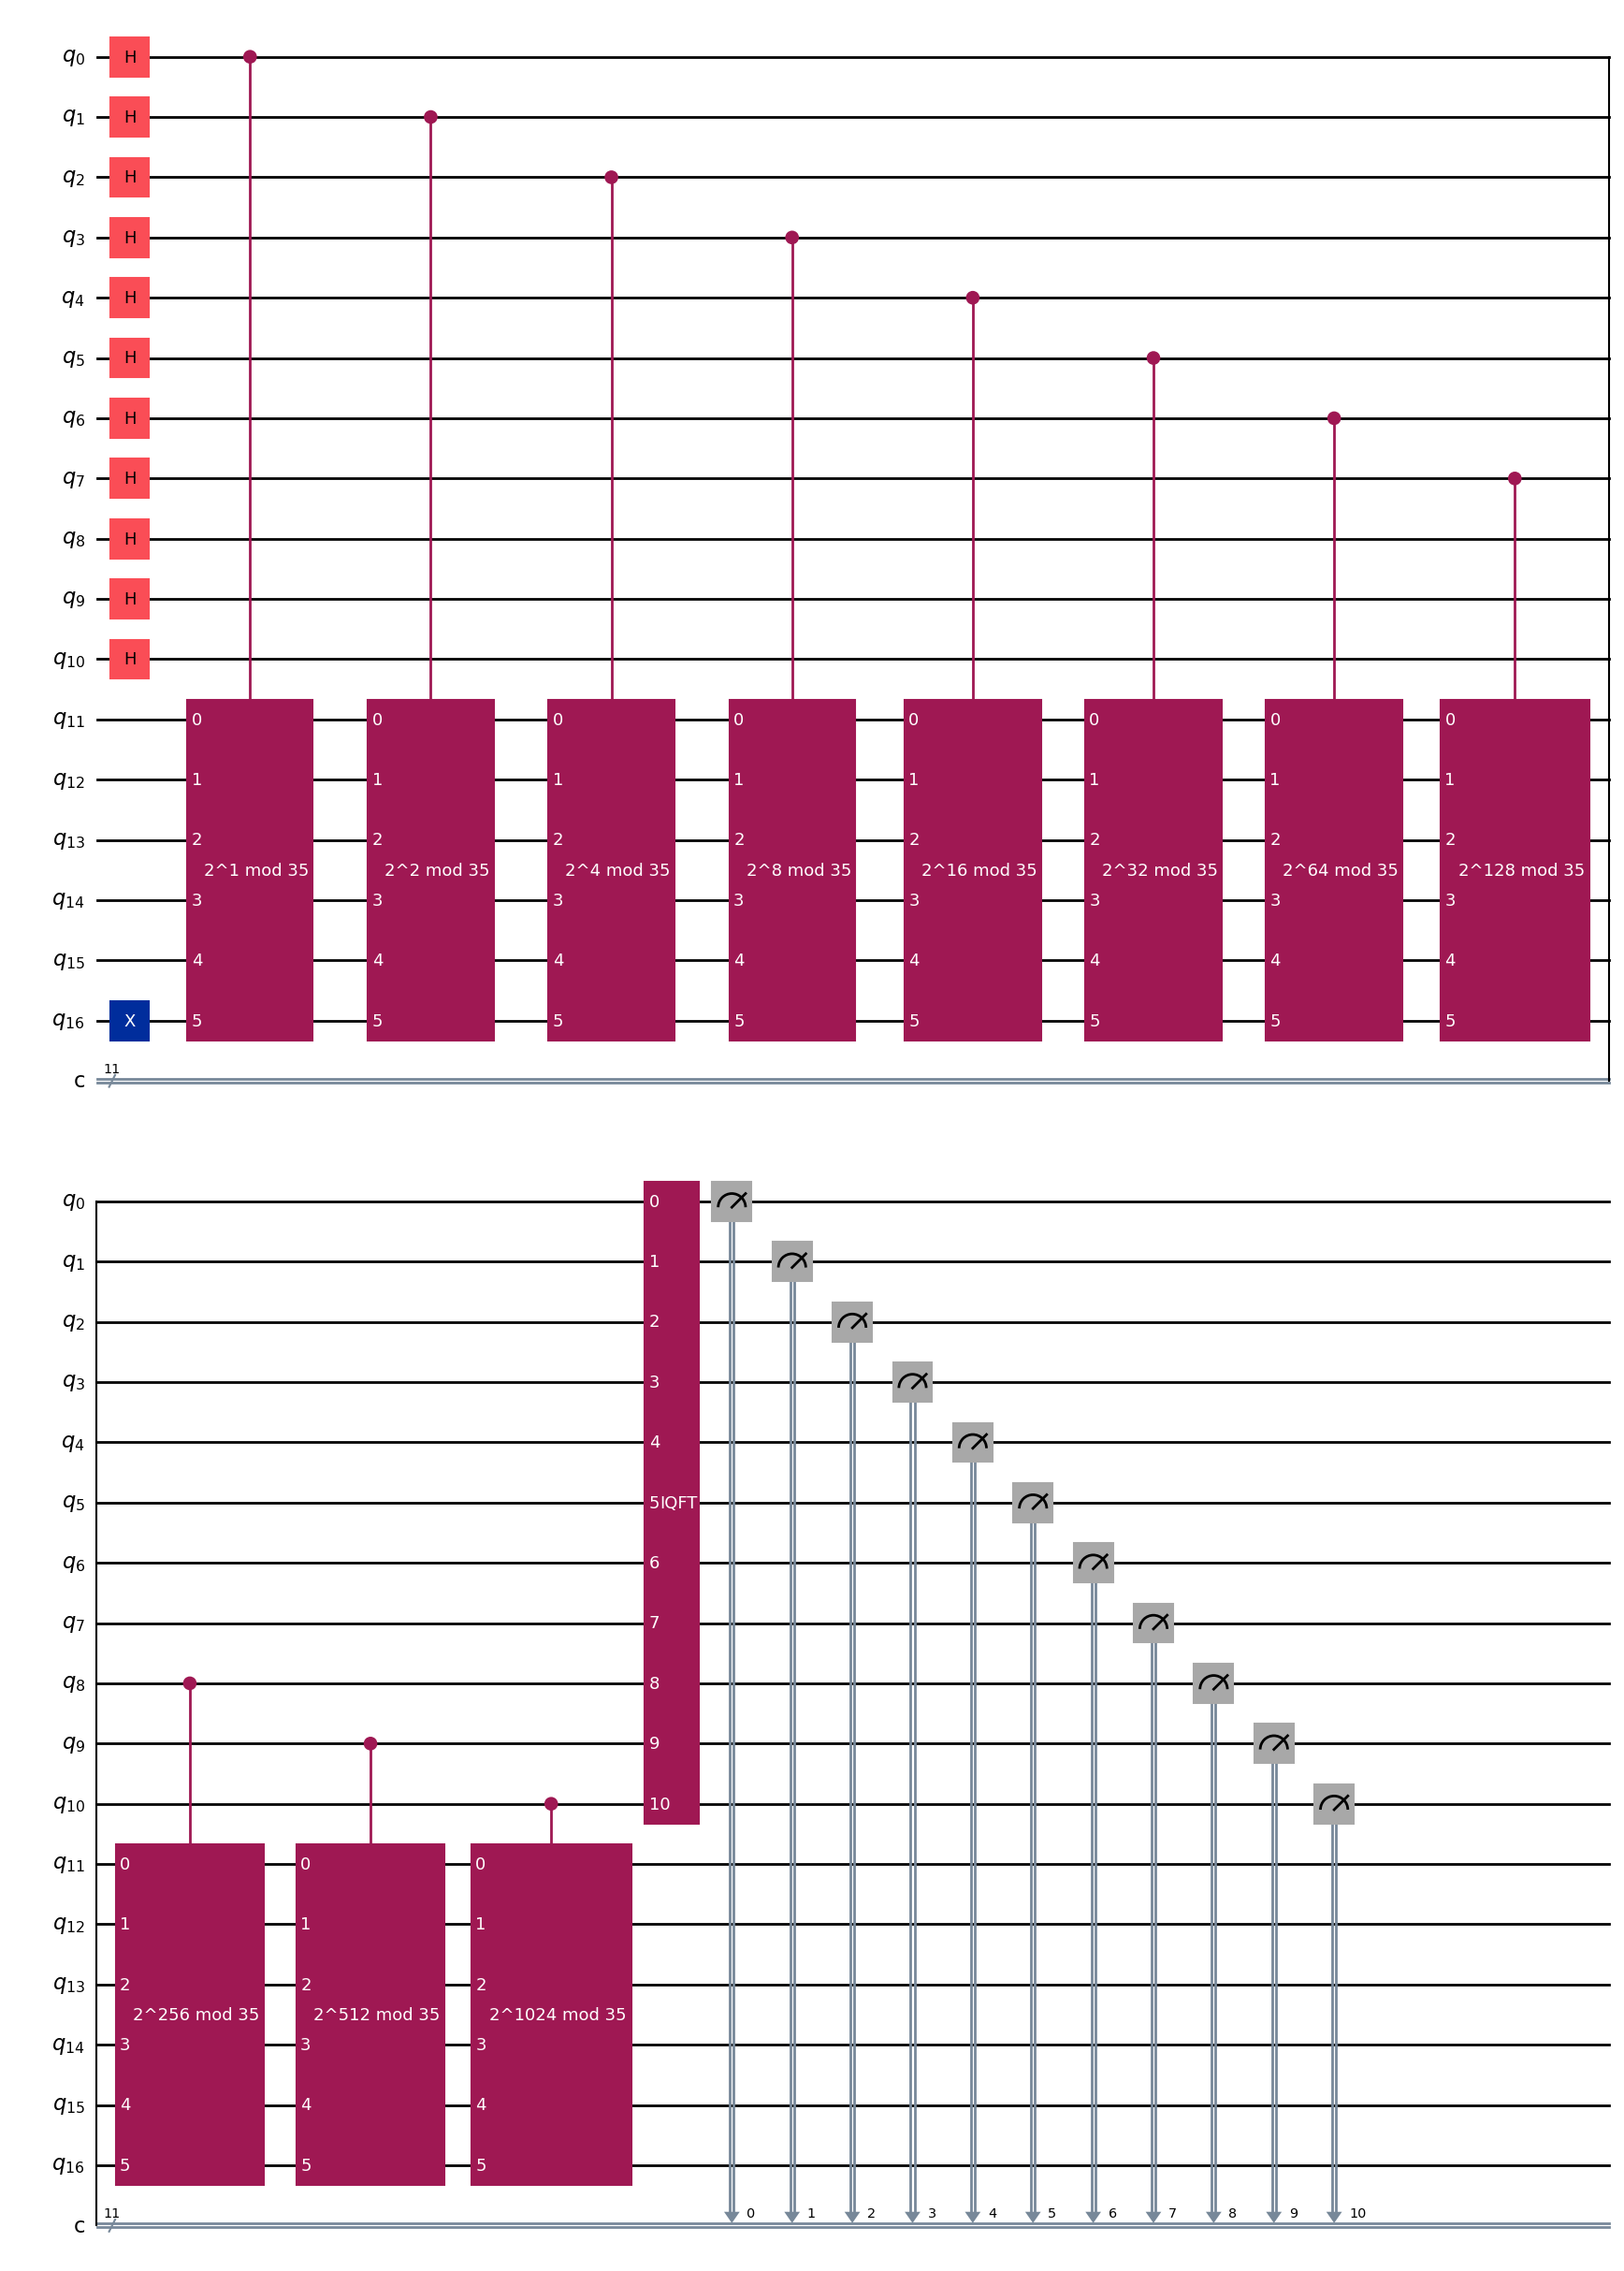

In [93]:
# Create the Quantum Circuit
qc = QuantumCircuit(CountingRegisterQubits + InitialStateQubits, CountingRegisterQubits)

# Apply Hadamards tot he Counting Registers to create Superposition
for q in range(CountingRegisterQubits):
    qc.h(q)
    
# Initialize the Initial state to superposition sum |1> = |0001> (This is done by applying a Not operation to the last qubit in the initial state)
qc.x(-1)

# Apply the Unitary U matrices
for q in range(CountingRegisterQubits):
    qc.append(c_amod35(x, 2**q), [q] + [i+CountingRegisterQubits for i in range(InitialStateQubits)])

# Apply Invserse QFT 
qc.append(QFT(CountingRegisterQubits).inverse(), range(CountingRegisterQubits))

# Add the measurements 
qc.measure(range(CountingRegisterQubits), range(CountingRegisterQubits))

# Draw to Visualize the Matrix
qc.draw('mpl')

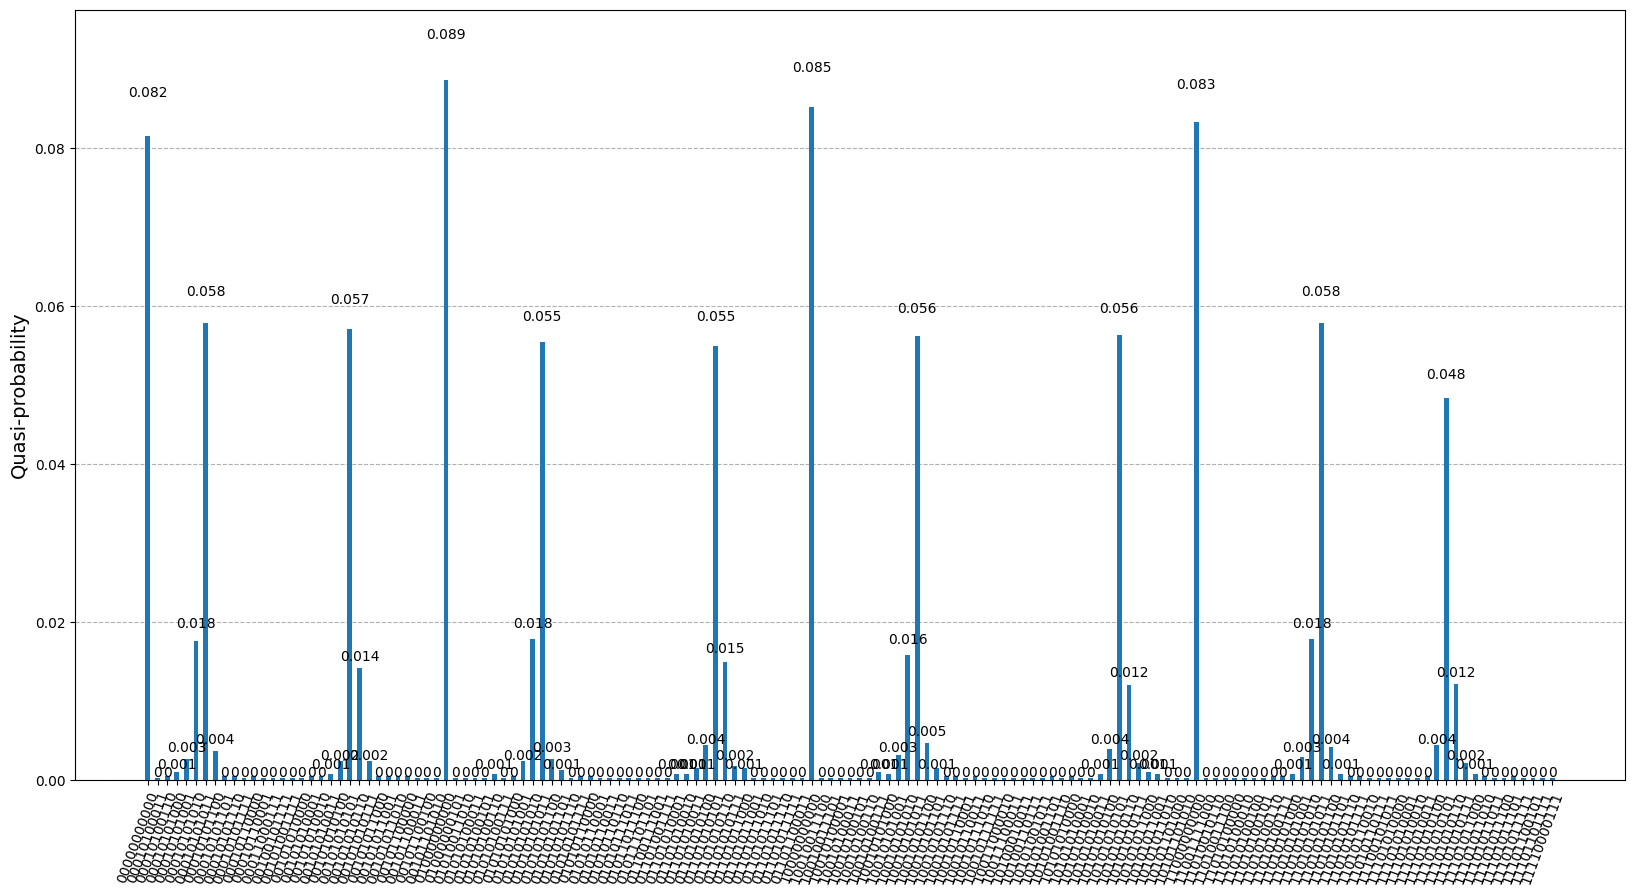

In [94]:
# Simulate the Circuit
# Initialize Circuit Simulation Components
sampler=AerSampler()
job_sim = sampler.run(qc , shots=4096)

# Simulate the Circuit and Plot the results in a Histogram
quasi_dists = job_sim.result().quasi_dists[0].binary_probabilities()
plot_histogram(quasi_dists, figsize=(20, 10))


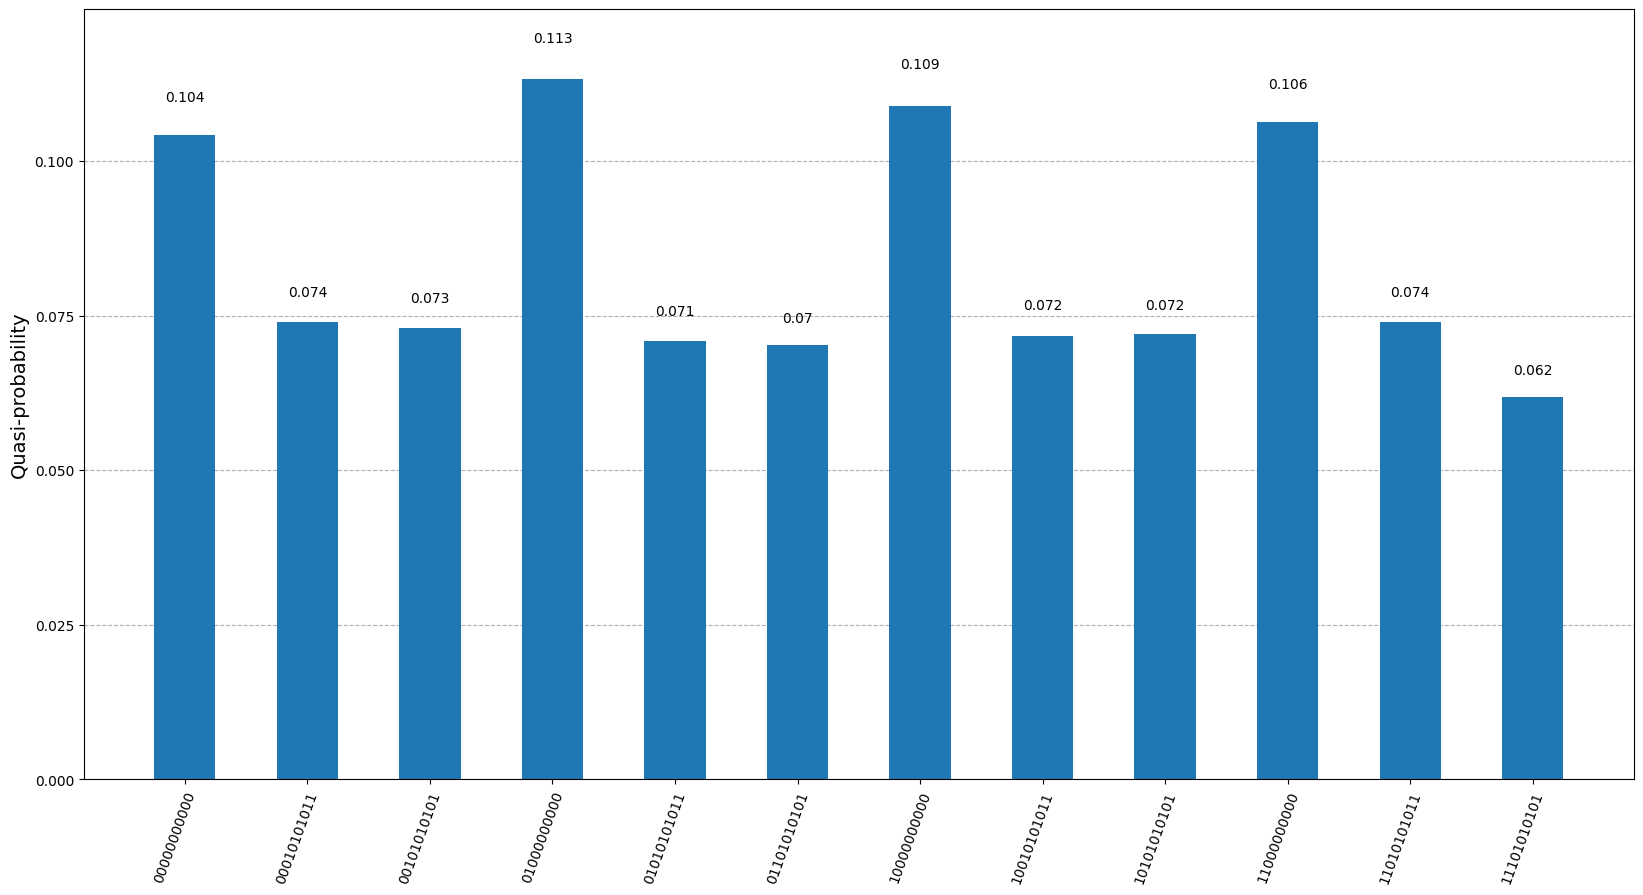

In [95]:
# Filter the results to reduce the 
threshold = 0.02
filtered_dists = {k: v for k, v in quasi_dists.items() if v > threshold}
plot_histogram(filtered_dists, figsize=(20, 10))

In [96]:
# Convert the Counting register to Integers 
intKeys = list(filtered_dists.keys())
intKeyDecimals = [int(k, 2) for k in intKeys]

# Calculate the s/r or Thetas
denom = 2**CountingRegisterQubits

thetas = [i / denom for i in intKeyDecimals]

# Calculate the r values using a fraction
rValues = [Fraction(y, denom).limit_denominator(N).denominator for y in intKeyDecimals]

print(f"Decimal Keys: {intKeyDecimals}")
print(f"Phases: {thetas}")
print(f"Candidate r values: {rValues}")

Decimal Keys: [1024, 512, 0, 1877, 171, 1536, 1365, 1195, 1707, 341, 683, 853]
Phases: [0.5, 0.25, 0.0, 0.91650390625, 0.08349609375, 0.75, 0.66650390625, 0.58349609375, 0.83349609375, 0.16650390625, 0.33349609375, 0.41650390625]
Candidate r values: [2, 4, 1, 12, 12, 4, 3, 12, 6, 6, 3, 12]


In [97]:
# Find the Factors that are equal to modulo 0
for r in rValues:
    # Skip if r is 0 (from y=0) or odd
    if r == 0 or r % 2 != 0:
        continue
        
    # Calculate x = a^(r/2) % N
    rDiv2 = r // 2
    x_val = pow(a, rDiv2, N)
    
    # Check if x + 1 is a multiple of N
    if (x_val + 1) % N == 0:
        continue
        
    # Calculate factors
    p = gcd(x_val + 1, N)
    q = gcd(x_val - 1, N)
    
    # If we found non-trivial factors, we are done
    if p > 1 and q > 1:
        print(f"\nSuccess found with r = {r}")
        print(f"The prime factors of {N} are :")
        print(f"p = {p}")
        print(f"q = {q}")
        break


Success found with r = 12
The prime factors of 35 are :
p = 5
q = 7
